In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)




data = pd.read_csv(r"C:\Users\samue\OneDrive\Desktop\ML Code\Proj1\aps+failure+at+scania+trucks\aps_failure_training_set.csv", skiprows=20)

In [ ]:
#print(data.shape)
data = data.replace('na',np.nan) #Replace word 'na' with nan value'

#split data into data (x) and label (y)
x = data.drop(columns='class')
y = data['class']

#split data
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size=0.2,random_state=5)#print(x.head(10))

#Impute x data & convert back to df
my_imputer = SimpleImputer(strategy='median',add_indicator=True)
imputed_x_train = pd.DataFrame(my_imputer.fit_transform(x_train))
imputed_x_val = pd.DataFrame(my_imputer.transform(x_val))

column_names = list(x_train.columns) #list of col names

for i in my_imputer.indicator_.features_: #each column name with atleats 1 nan value
    column_names.append(x_train.columns[i] + "_missing") #add that name + "_missing" to column name list


#Put col names back since imputer removed
imputed_x_train.columns = column_names
imputed_x_val.columns = column_names



0


In [ ]:
#create dummy model for baseline
print(y.value_counts())
dummy_outputs = y.value_counts().tolist()
dummy_neg = outputs[0]
dummy_y_pos = outputs[1]
dummy_y_pred = np.full(len(y_val), 'neg')

dummy_accuracy = accuracy_score(y_val, dummy_y_pred)
dummy_precision = precision_score(y_val, dummy_y_pred, pos_label='pos')
dummy_recall = recall_score(y_val, dummy_y_pred, pos_label='pos')
dummy_f1 = f1_score(y_val, dummy_y_pred, pos_label='pos')

print(f"Accuracy:   {dummy_accuracy:.4f}")
print(f"Precision:  {dummy_precision:.4f}")
print(f"Recall:     {dummy_recall:.4f}")
print(f"F1 Score:   {dummy_f1:.4f}")

dummy_stats = [dummy_accuracy,dummy_precision,dummy_recall,dummy_f1]


class
neg    59000
pos     1000
Name: count, dtype: int64
Accuracy:   0.9842
Precision:  0.9842
Recall:     1.0000
F1 Score:   0.9920


In [ ]:
#create and train model
model = DecisionTreeClassifier(random_state=3)
model.fit(x_train,y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [ ]:
#make predictions
y_pred = model.predict(x_val)


0.9895


In [ ]:
#calculate metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, pos_label='pos')
recall = recall_score(y_val, y_pred, pos_label='pos')
f1 = f1_score(y_val, y_pred, pos_label='pos')

print(f"Accuracy:   {accuracy:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1:.4f}")

Accuracy:   0.9895
Precision:  0.9954
Recall:     0.9939
F1 Score:   0.9947


[[11738    72]
 [   54   136]]


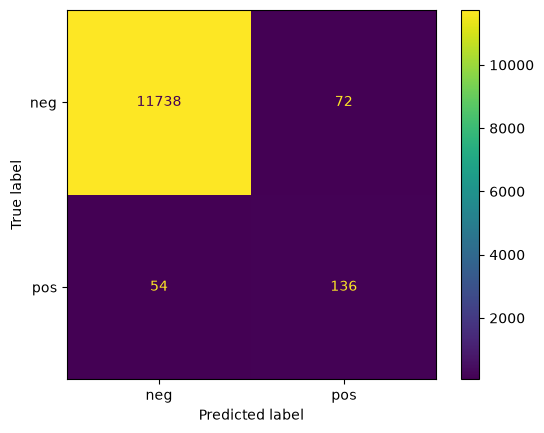

In [ ]:
#confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred)